# **EDA**

In [1]:
# --- Local setup (replaces Colab google.drive mount) ---
%matplotlib inline
import os
BASE_DIR = r'/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset'
print('Using local dataset at:', BASE_DIR)
print('exists:', os.path.isdir(BASE_DIR))


Using local dataset at: /home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset
exists: True


In [2]:
import numpy as np
import pandas as pd

# get the features from the file features.txt
features = list()
with open('/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset/features.txt') as f:
    features = [line.split()[1] for line in f.readlines()]
print('No of Features: {}'.format(len(features)))

No of Features: 561


# **Getting the train data**

In [3]:
# get the data from txt files to pandas dataffame
X_train = pd.read_csv('/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
X_train.columns = [features]
# add subject column to the dataframe
X_train['subject'] = pd.read_csv('/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset/train/subject_train.txt', header=None).iloc[:, 0]

y_train = pd.read_csv('/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset/train/y_train.txt', names=['Activity'], header=None).iloc[:, 0]
y_train_labels = y_train.map({1: 'WALKING', 2:'WALKING_UPSTAIRS',3:'WALKING_DOWNSTAIRS',\
                       4:'SITTING', 5:'STANDING',6:'LAYING'})

# put all columns in a single dataframe
train = X_train
train['Activity'] = y_train
train['ActivityName'] = y_train_labels
train.sample(2)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_60494/1333566282.py:2: SyntaxWarning: invalid escape sequence '\s'
  X_train = pd.read_csv('/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
/tmp/ipykernel_60494/1333566282.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['subject'] = pd.read_csv('/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset/train/subject_train.txt', header=None).iloc[:, 0]
/tmp/ipykernel_60494/1333566282.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,ActivityName
5082,0.278372,-0.018324,-0.109368,-0.996676,-0.964301,-0.985914,-0.996683,-0.961909,-0.983512,-0.941514,...,-0.120295,0.037329,-0.108622,0.216319,-0.660024,0.200909,-0.201196,25,5,STANDING
6583,0.199481,-0.038734,-0.182681,0.088036,0.057492,-0.310572,0.018470,0.048940,-0.336619,0.324988,...,0.224609,-0.803731,0.884227,-0.647239,-0.760429,0.243027,0.100365,28,3,WALKING_DOWNSTAIRS


In [4]:
train.shape

(7352, 564)

# **Getting the test data**

In [5]:
# get the data from txt files to pandas dataffame
X_test = pd.read_csv('/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None)
X_test.columns = [features]
# add subject column to the dataframe
X_test['subject'] = pd.read_csv('/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset/test/subject_test.txt', header=None).iloc[:, 0]

# get y labels from the txt file
y_test = pd.read_csv('/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset/test/y_test.txt', names=['Activity'], header=None).iloc[:, 0]
y_test_labels = y_test.map({1: 'WALKING', 2:'WALKING_UPSTAIRS',3:'WALKING_DOWNSTAIRS',\
                       4:'SITTING', 5:'STANDING',6:'LAYING'})


# put all columns in a single dataframe
test = X_test
test['Activity'] = y_test
test['ActivityName'] = y_test_labels
test.sample(2)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_60494/835220256.py:2: SyntaxWarning: invalid escape sequence '\s'
  X_test = pd.read_csv('/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None)
/tmp/ipykernel_60494/835220256.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['subject'] = pd.read_csv('/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset/test/subject_test.txt', header=None).iloc[:, 0]
/tmp/ipykernel_60494/835220256.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,ActivityName
1379,0.269634,-0.048745,-0.109304,-0.978010,-0.866620,-0.934643,-0.980242,-0.869758,-0.930538,-0.921533,...,-0.027850,0.011025,0.318778,-0.306157,-0.848590,0.202408,0.027719,12,5,STANDING
1074,0.274905,-0.014076,-0.110867,-0.997158,-0.975103,-0.972583,-0.997531,-0.972196,-0.968548,-0.943546,...,0.087936,0.586501,-0.908241,0.786481,-0.811879,-0.035605,0.017415,10,5,STANDING


In [6]:
test.shape

(2947, 564)

# **Data Cleaning**

## **0. Convert Walkings to Moving**

In [7]:
# Convert ActivityName "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS" to "MOVING"
train["ActivityName"] = train["ActivityName"].replace(
    ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS"],
    "MOVING"
)
train["ActivityName"].value_counts()

/tmp/ipykernel_60494/3497828853.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  train["ActivityName"] = train["ActivityName"].replace(


(ActivityName,)
MOVING             3285
LAYING             1407
STANDING           1374
SITTING            1286
Name: count, dtype: int64

In [8]:
# Convert ActivityName "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS" to "MOVING"
test["ActivityName"] = test["ActivityName"].replace(
    ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS"],
    "MOVING"
)
test["ActivityName"].value_counts()

/tmp/ipykernel_60494/1274554907.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  test["ActivityName"] = test["ActivityName"].replace(


(ActivityName,)
MOVING             1387
LAYING              537
STANDING            532
SITTING             491
Name: count, dtype: int64

# **JUST TRAINING**

In [9]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from datetime import datetime

from sklearn import linear_model
from sklearn import metrics

from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

X_train = train.drop(['subject', 'Activity', 'ActivityName'], axis=1)
y_train = train.ActivityName

X_test = test.drop(['subject', 'Activity', 'ActivityName'], axis=1)
y_test = test.ActivityName

print('X_train and y_train : ({},{})'.format(X_train.shape, y_train.shape))
print('X_test  and y_test  : ({},{})'.format(X_test.shape, y_test.shape))

labels = ['LAYING', 'SITTING','STANDING','MOVING']
labels

plt.rcParams["font.family"] = 'DejaVu Sans'

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

def perform_model(model, X_train, y_train, X_test, y_test, class_labels, cm_normalize=True, \
                 print_cm=True, cm_cmap=plt.cm.Greens):


    # to store results at various phases
    results = dict()

    # time at which model starts training
    train_start_time = datetime.now()
    print('training the model..')
    model.fit(X_train, y_train)
    print('Done....!\n')
    train_end_time = datetime.now()
    results['training_time'] =  train_end_time - train_start_time
    print('==> training time:- {}\n'.format(results['training_time']))


    # predict test data
    print('Predicting test data')
    test_start_time = datetime.now()
    y_pred = model.predict(X_test)
    test_end_time = datetime.now()
    print('Done....!\n')
    results['testing_time'] = test_end_time - test_start_time
    print('==> testing time:- {}\n'.format(results['testing_time']))
    results['predicted'] = y_pred


    # calculate overall accuracty of the model
    accuracy = metrics.accuracy_score(y_true=y_test, y_pred=y_pred)
    # store accuracy in results
    results['accuracy'] = accuracy
    print('==> Accuracy:- {}\n'.format(accuracy))



    # confusion matrix
    cm = metrics.confusion_matrix(y_test, y_pred)
    results['confusion_matrix'] = cm
    if print_cm:
        print('\n ********Confusion Matrix********')
        print('\n {}'.format(cm))

    # plot confusin matrix
    plt.figure(figsize=(6,6))
    plt.grid(visible=False)
    plot_confusion_matrix(cm, classes=class_labels, normalize=True, title='Normalized confusion matrix', cmap = cm_cmap)
    plt.show()

    # get classification report
    print('****************| Classifiction Report |****************')
    classification_report = metrics.classification_report(y_test, y_pred)

    # store report in results
    results['classification_report'] = classification_report
    print(classification_report)

    # add the trained  model to the results
    results['model'] = model

    return results

def print_grid_search_attributes(model):
    # Estimator that gave highest score among all the estimators formed in GridSearch
    print('\n\n==> Best Estimator:')
    print('\t{}\n'.format(model.best_estimator_))


    # parameters that gave best results while performing grid search
    print('\n==> Best parameters:')
    print('\tParameters of best estimator : {}'.format(model.best_params_))


    #  number of cross validation splits
    print('\n==> No. of CrossValidation sets:')
    print('\tTotal numbre of cross validation sets: {}'.format(model.n_splits_))


    # Average cross validated score of the best estimator, from the Grid Search
    print('\n==> Best Score:')
    print('\tAverage Cross Validate scores of best estimator : {}'.format(model.best_score_))

parameters = {'C':[0.125, 0.5, 1, 2, 8, 16]}
lr_svc = LinearSVC(tol=0.00005)
lr_svc_grid = GridSearchCV(lr_svc, param_grid=parameters, n_jobs=4, verbose=1)
lr_svc_grid_results = perform_model(lr_svc_grid, X_train, y_train, X_test, y_test, class_labels=labels)

# observe the attributes of the model
print_grid_search_attributes(lr_svc_grid_results['model'])

X_train and y_train : ((7352, 561),(7352, 1))
X_test  and y_test  : ((2947, 561),(2947, 1))
training the model..
Fitting 5 folds for each of 6 candidates, totalling 30 fits


ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/home/voare/Documents/Synheart/Kinematics/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/voare/Documents/Synheart/Kinematics/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/voare/Documents/Synheart/Kinematics/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py", line 314, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/home/voare/Documents/Synheart

## **1. Check for Duplicates**

In [ ]:
print('No of duplicates in train: {}'.format(sum(train.duplicated())))
print('No of duplicates in test : {}'.format(sum(test.duplicated())))

/tmp/ipykernel_44802/408555551.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  print('No of duplicates in train: {}'.format(sum(train.duplicated())))


No of duplicates in train: 0
No of duplicates in test : 0


/tmp/ipykernel_44802/408555551.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  print('No of duplicates in test : {}'.format(sum(test.duplicated())))


## **2. Checking for NaN/null values**

In [ ]:
print('We have {} NaN/Null values in train'.format(train.isnull().values.sum()))
print('We have {} NaN/Null values in test'.format(test.isnull().values.sum()))

We have 0 NaN/Null values in train


We have 0 NaN/Null values in test


## **3. Save this dataframe in a csv files**

In [ ]:
import os

output_dir = 'UCI_HAR_Dataset/csv_files'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

train.to_csv(os.path.join(output_dir, 'train.csv'), index=False)
test.to_csv(os.path.join(output_dir, 'test.csv'), index=False)

# **Exploratory Data Analysis**

## **Obtain the train and test data**

In [ ]:
train = pd.read_csv('UCI_HAR_Dataset/csv_files/train.csv')
test = pd.read_csv('UCI_HAR_Dataset/csv_files/test.csv')
print(train.shape, test.shape)

(7352, 564) (2947, 564)


## **All the feature name with lots of unnecessary singhs: Changing feature names**

In [ ]:
columns = train.columns

# Removing '()' from column names
# Using regex=True for patterns like '()', '-', ',' to ensure proper replacement
columns = columns.str.replace(r'[()]','', regex=True)
columns = columns.str.replace(r'[-]', '', regex=True)
columns = columns.str.replace(r'[,]','', regex=True)

train.columns = columns
test.columns = columns

test.columns

Index(['tBodyAccmeanX', 'tBodyAccmeanY', 'tBodyAccmeanZ', 'tBodyAccstdX',
       'tBodyAccstdY', 'tBodyAccstdZ', 'tBodyAccmadX', 'tBodyAccmadY',
       'tBodyAccmadZ', 'tBodyAccmaxX',
       ...
       'angletBodyAccMeangravity', 'angletBodyAccJerkMeangravityMean',
       'angletBodyGyroMeangravityMean', 'angletBodyGyroJerkMeangravityMean',
       'angleXgravityMean', 'angleYgravityMean', 'angleZgravityMean',
       'subject', 'Activity', 'ActivityName'],
      dtype='str', length=564)

## **1. investigate participants activity durations.**

Since the dataset has been created in a scientific environment nearly equal preconditions for the participants can be assumed. Let us investigate their activity durations.

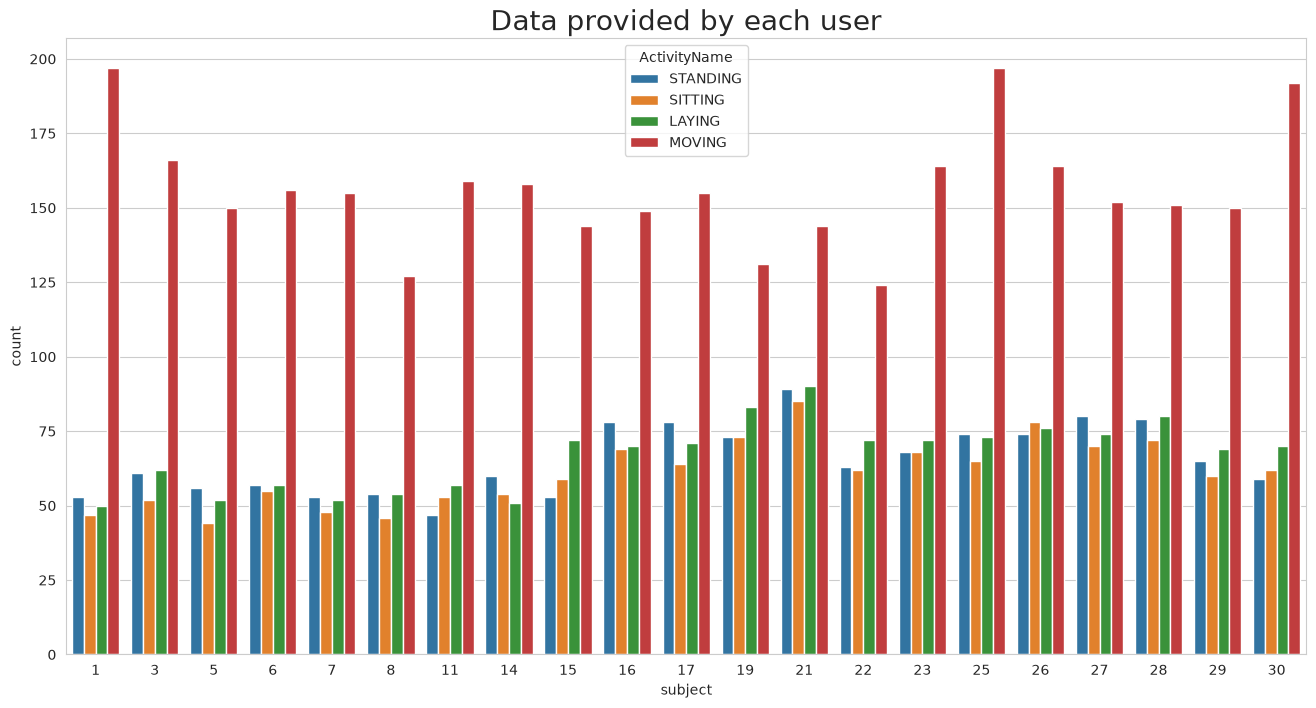

In [ ]:
import matplotlib as mlt
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Dejavu Sans'

plt.figure(figsize=(16,8))
plt.title('Data provided by each user', fontsize=20)
sns.countplot(x='subject',hue='ActivityName', data = train)
plt.show()

Nearly all participants have more data for walking upstairs than downstairs. Assuming an equal number of up- and down-walks the participants need longer walking upstairs.

## **How Are The ActivityName Distributed?**

In [ ]:
import plotly
import plotly.graph_objects as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot


# Plotting data
label_counts = train['ActivityName'].value_counts()

# Get colors
n = label_counts.shape[0]
colormap = plt.get_cmap('viridis')
colors = [mlt.colors.to_hex(colormap(col)) for col in np.arange(0, 1.01, 1/(n-1))]

# Create plot
data = go.Bar(x = label_counts.index,
              y = label_counts,
              marker = dict(color = colors))

layout = go.Layout(title = 'Smartphone ActivityName Distribution',
                   xaxis = dict(title = 'ActivityName'),
                   yaxis = dict(title = 'Count'))

fig = go.Figure(data=[data], layout=layout)
fig.show()
#iplot(fig)

- Although there are fluctuations in the label counts, the labels are quite equally distributed.

- Assuming the participants had to walk the same number of stairs upwards as well as downwards and knowing the smartphones had a constant sampling rate, there should be the same amount of datapoints for walking upstairs and downstairs.

- Disregarding the possibility of flawed data, the participants seem to walk roughly 10% faster downwards.

## **2. Featuring Engineering from Domain Knowledge**

### **Static and Dynamic Activities**

- In static activities (sit, stand, lie down) motion information will not be very useful.
- In the dynamic activities (Walking, WalkingUpstairs,WalkingDownstairs) motion info will be significant.

## **3. Stationary and Moving activities are completely different**

/home/voare/Documents/Synheart/Kinematics/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/home/voare/Documents/Synheart/Kinematics/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed297

/home/voare/Documents/Synheart/Kinematics/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


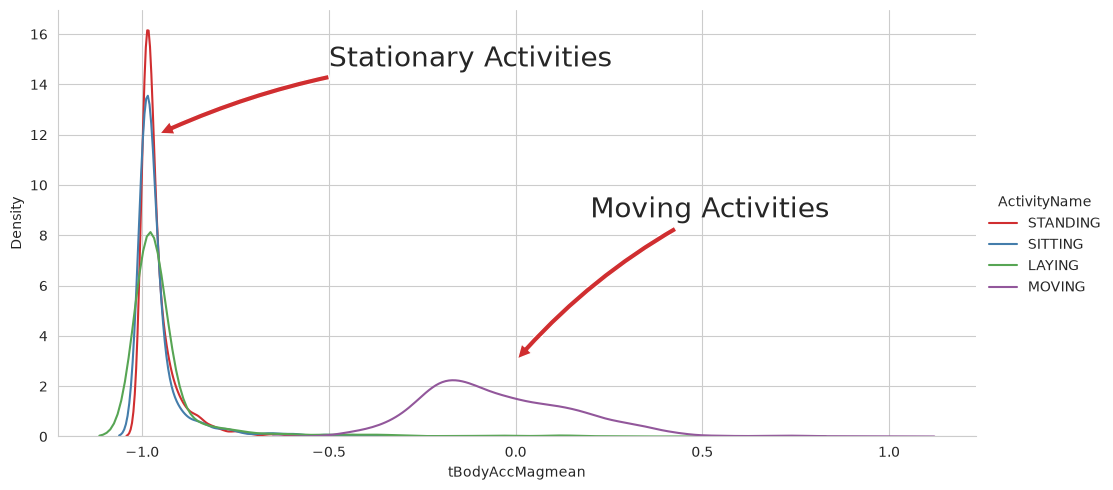

In [ ]:
sns.set_palette("Set1", desat=0.80)
facetgrid = sns.FacetGrid(train, hue='ActivityName', height=5,aspect=2)
facetgrid.map(sns.distplot,'tBodyAccMagmean', hist=False)\
    .add_legend()
plt.annotate("Stationary Activities", xy=(-0.960,12), xytext=(-0.5, 15), size=20,\
            va='center', ha='left',\
            arrowprops=dict(arrowstyle="simple",connectionstyle="arc3,rad=0.1"))

plt.annotate("Moving Activities", xy=(0,3), xytext=(0.2, 9), size=20,\
            va='center', ha='left',\
            arrowprops=dict(arrowstyle="simple",connectionstyle="arc3,rad=0.1"))
plt.show()

As aspected from most real world data, when participants are moving the data is normally distributed with some long tail.

/tmp/ipykernel_44802/1112189619.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df4['tBodyAccMagmean'],color = 'r',hist = False, label = 'Sitting')
/tmp/ipykernel_44802/1112189619.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df5['tBodyAccMagmean'],color = 'm',hist 

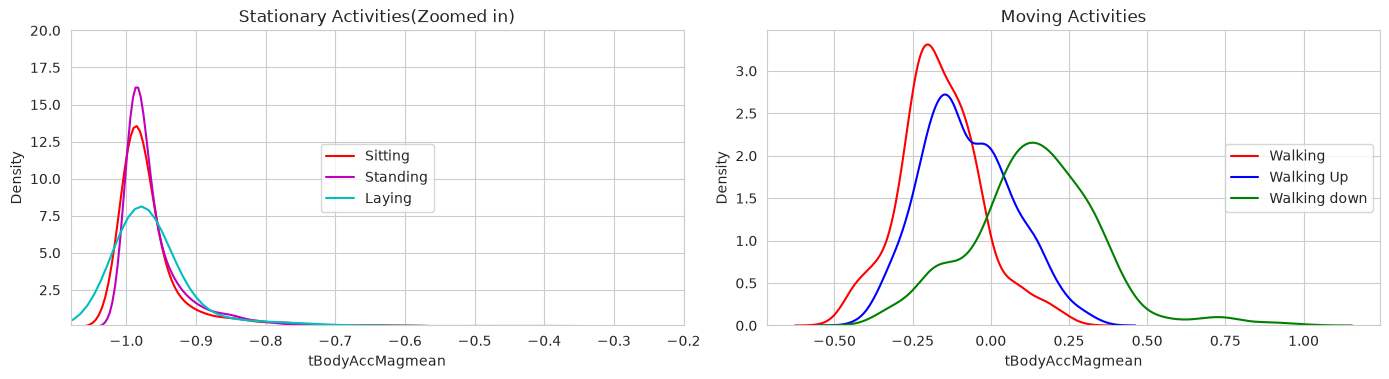

In [ ]:
# for plotting purposes taking datapoints of each activity to a different dataframe
df1 = train[train['Activity']==1]
df2 = train[train['Activity']==2]
df3 = train[train['Activity']==3]
df4 = train[train['Activity']==4]
df5 = train[train['Activity']==5]
df6 = train[train['Activity']==6]

plt.figure(figsize=(14,7))
plt.subplot(2,2,1)
plt.title('Stationary Activities(Zoomed in)')
sns.distplot(df4['tBodyAccMagmean'],color = 'r',hist = False, label = 'Sitting')
sns.distplot(df5['tBodyAccMagmean'],color = 'm',hist = False,label = 'Standing')
sns.distplot(df6['tBodyAccMagmean'],color = 'c',hist = False, label = 'Laying')
plt.axis([-1.08, -0.2, 0.1, 20])
plt.legend(loc='center')

plt.subplot(2,2,2)
plt.title('Moving Activities')
sns.distplot(df1['tBodyAccMagmean'],color = 'red',hist = False, label = 'Walking')
sns.distplot(df2['tBodyAccMagmean'],color = 'blue',hist = False,label = 'Walking Up')
sns.distplot(df3['tBodyAccMagmean'],color = 'green',hist = False, label = 'Walking down')
plt.legend(loc='center right')


plt.tight_layout()
plt.show()

We can see clearly here, the distribuation of Stationary Activities and Moving Activities.

## **4. Magnitude of an acceleration can saperate it well**

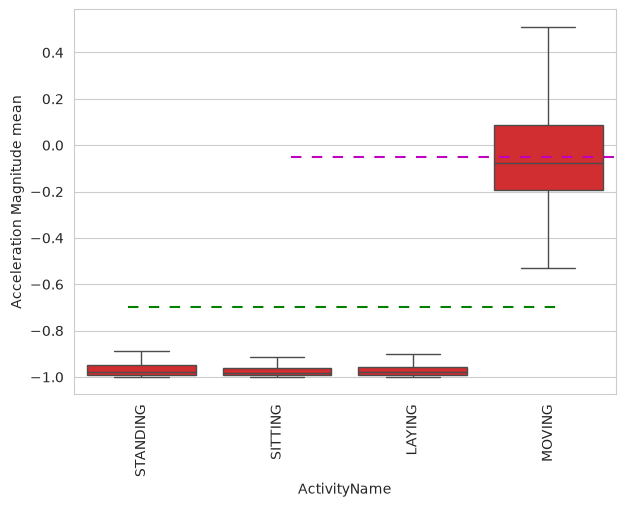

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='ActivityName', y='tBodyAccMagmean',data=train, showfliers=False, saturation=1)
plt.ylabel('Acceleration Magnitude mean')
plt.axhline(y=-0.7, xmin=0.1, xmax=0.9,dashes=(5,5), c='g')
plt.axhline(y=-0.05, xmin=0.4, dashes=(5,5), c='m')
plt.xticks(rotation=90)
plt.show()

- If tAccMean is < -0.8 then the Activities are either Standing or Sitting or Laying.
- If tAccMean is > -0.6 then the Activities are either Walking or WalkingDownstairs or WalkingUpstairs.
- If tAccMean > 0.0 then the Activity is WalkingDownstairs.
- We can classify 75% the Acitivity labels with some errors.

## **5. Position of GravityAccelerationComponants also matters**

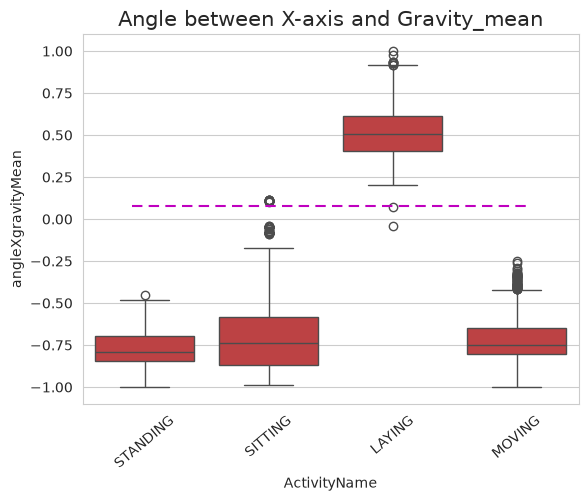

In [ ]:
sns.boxplot(x='ActivityName', y='angleXgravityMean', data=train)
plt.axhline(y=0.08, xmin=0.1, xmax=0.9,c='m',dashes=(5,3))
plt.title('Angle between X-axis and Gravity_mean', fontsize=15)
plt.xticks(rotation = 40)
plt.show()

- If angleX,gravityMean > 0 then Activity is Laying.
- We can classify all datapoints belonging to Laying activity with just a single if else statement.

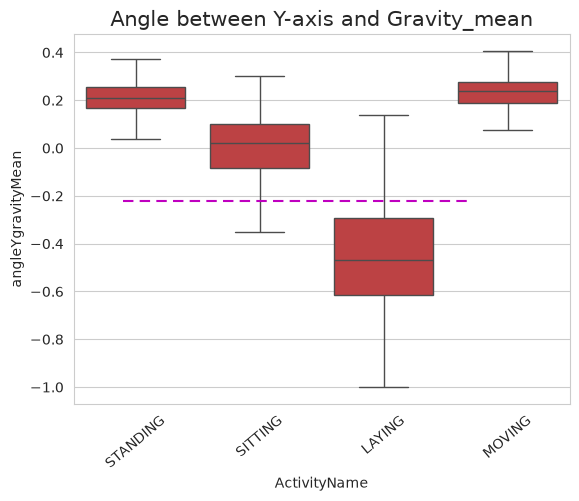

In [ ]:
sns.boxplot(x='ActivityName', y='angleYgravityMean', data = train, showfliers=False)
plt.title('Angle between Y-axis and Gravity_mean', fontsize=15)
plt.xticks(rotation = 40)
plt.axhline(y=-0.22, xmin=0.1, xmax=0.8, dashes=(5,3), c='m')
plt.show()

# **Apply t-sne on the data**
### **Are The Activities Separable?**
The dataset is geared towards classifying the activity of the participant. Let us investigate the separability of the classes.

In [ ]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# performs t-sne with different perplexity values and their repective plots..

def perform_tsne(X_data, y_data, perplexities, n_iter=1000, img_name_prefix='t-sne'):

    for index,perplexity in enumerate(perplexities):
        # perform t-sne
        print('\nperforming tsne with perplexity {} and with {} iterations at max'.format(perplexity, n_iter))
        X_reduced = TSNE(verbose=2, perplexity=perplexity).fit_transform(X_data)
        print('Done..')

        # prepare the data for seaborn
        print('Creating plot for this t-sne visualization..')
        df = pd.DataFrame({'x':X_reduced[:,0], 'y':X_reduced[:,1] ,'label':y_data})

        # draw the plot in appropriate place in the grid
        sns.lmplot(data=df, x='x', y='y', hue='label', fit_reg=False, height=8,\
                   palette="Set1",markers=['^','v','s','o','1','2'][:df['label'].nunique()])
        plt.title("perplexity : {} and max_iter : {}".format(perplexity, n_iter))
        img_name = img_name_prefix + '_perp_{}_iter_{}.png'.format(perplexity, n_iter)
        print('saving this plot as image in present working directory...')
        plt.savefig(img_name)
        plt.show()
        print('Done')


performing tsne with perplexity 2 and with 1000 iterations at max
[t-SNE] Computing 7 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.022s...


[t-SNE] Computed neighbors for 7352 samples in 1.180s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 0.597443
[t-SNE] Computed conditional probabilities in 0.016s


[t-SNE] Iteration 50: error = 119.3247986, gradient norm = 0.0444176 (50 iterations in 2.562s)


[t-SNE] Iteration 100: error = 105.0440826, gradient norm = 0.0251558 (50 iterations in 1.378s)


[t-SNE] Iteration 150: error = 99.7569885, gradient norm = 0.0167238 (50 iterations in 1.225s)


...

[t-SNE] Iteration 850: error = 1.7506163, gradient norm = 0.0066842 (50 iterations in 1.080s)


[t-SNE] Iteration 900: error = 1.7045070, gradient norm = 0.0063493 (50 iterations in 1.080s)


[t-SNE] Iteration 950: error = 1.6631961, gradient norm = 0.0060903 (50 iterations in 1.075s)


[t-SNE] Iteration 1000: error = 1.6258432, gradient norm = 0.0058403 (50 iterations in 1.078s)
[t-SNE] KL divergence after 1000 iterations: 1.625843
Done..
Creating plot for this t-sne visualization..


saving this plot as image in present working directory...


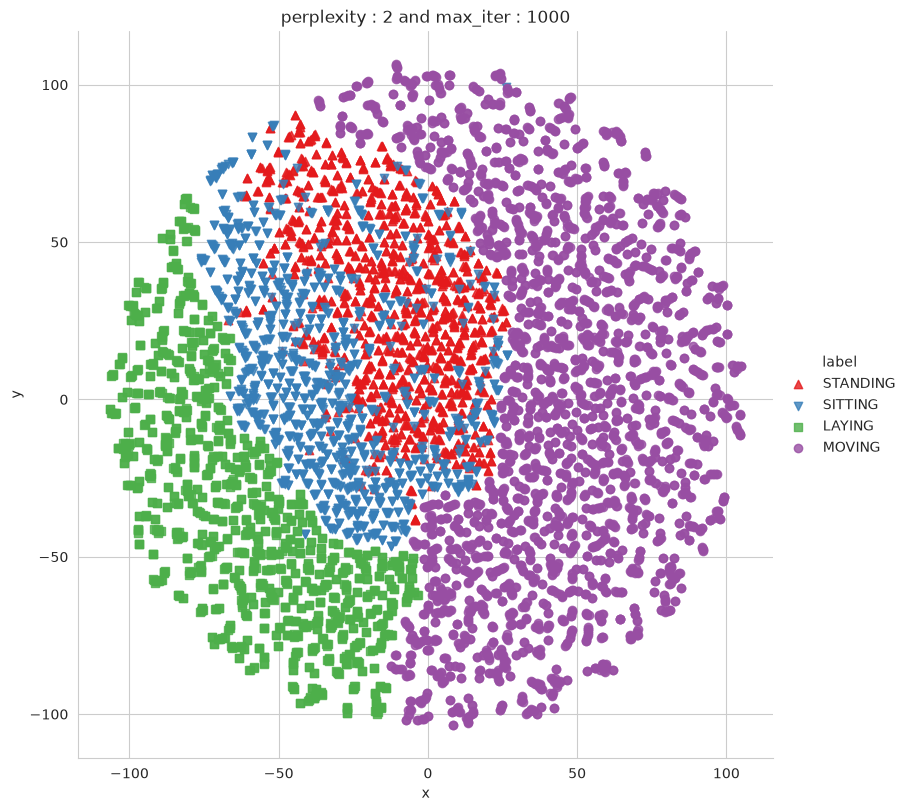

Done

performing tsne with perplexity 5 and with 1000 iterations at max
[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.021s...


[t-SNE] Computed neighbors for 7352 samples in 1.157s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 0.961446
[t-SNE] Computed conditional probabilities in 0.028s


[t-SNE] Iteration 50: error = 107.1288605, gradient norm = 0.0378796 (50 iterations in 3.016s)


[t-SNE] Iteration 100: error = 95.6592407, gradient norm = 0.0154773 (50 iterations in 1.432s)


[t-SNE] Iteration 150: error = 92.4120941, gradient norm = 0.0098937 (50 iterations in 1.310s)


...

[t-SNE] Iteration 850: error = 1.6615187, gradient norm = 0.0066447 (50 iterations in 1.209s)


[t-SNE] Iteration 900: error = 1.6301062, gradient norm = 0.0063746 (50 iterations in 1.245s)


[t-SNE] Iteration 950: error = 1.6023808, gradient norm = 0.0059908 (50 iterations in 1.328s)


[t-SNE] Iteration 1000: error = 1.5776858, gradient norm = 0.0057335 (50 iterations in 1.247s)
[t-SNE] KL divergence after 1000 iterations: 1.577686
Done..
Creating plot for this t-sne visualization..


saving this plot as image in present working directory...


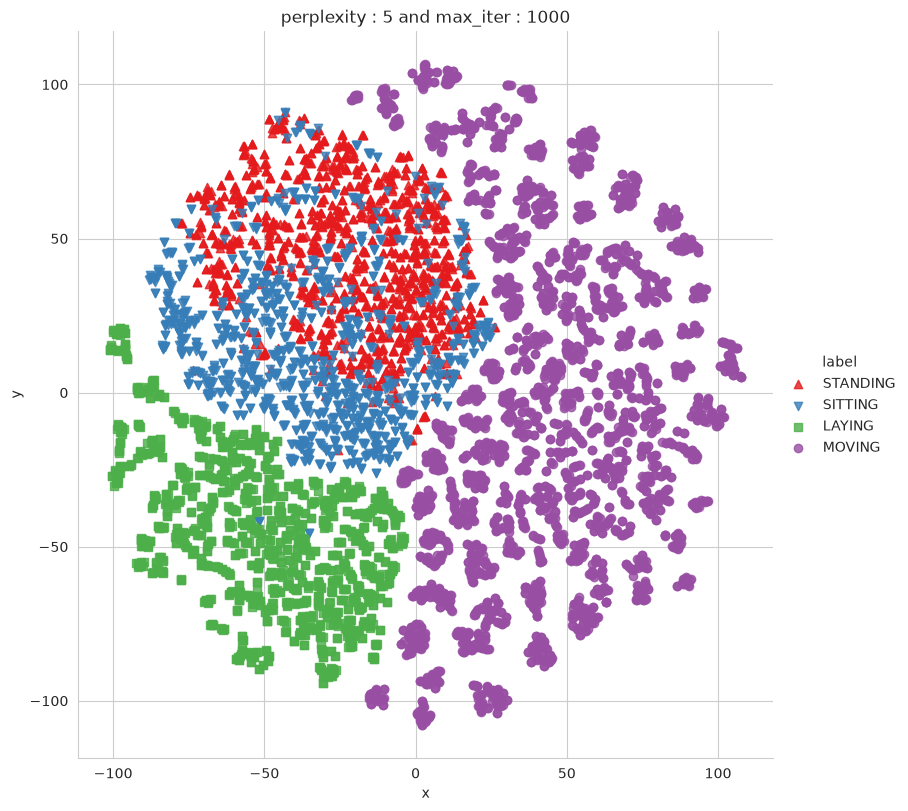

Done

performing tsne with perplexity 10 and with 1000 iterations at max
[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.025s...


[t-SNE] Computed neighbors for 7352 samples in 1.180s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 1.133827
[t-SNE] Computed conditional probabilities in 0.053s


[t-SNE] Iteration 50: error = 97.8762817, gradient norm = 0.0376792 (50 iterations in 2.796s)


[t-SNE] Iteration 100: error = 89.0052719, gradient norm = 0.0104423 (50 iterations in 1.446s)


[t-SNE] Iteration 150: error = 86.7849426, gradient norm = 0.0063079 (50 iterations in 1.306s)


...

[t-SNE] Iteration 850: error = 1.5651717, gradient norm = 0.0062478 (50 iterations in 1.125s)


[t-SNE] Iteration 900: error = 1.5436832, gradient norm = 0.0056773 (50 iterations in 1.150s)


[t-SNE] Iteration 950: error = 1.5257847, gradient norm = 0.0052013 (50 iterations in 1.139s)


[t-SNE] Iteration 1000: error = 1.5103464, gradient norm = 0.0048079 (50 iterations in 1.147s)
[t-SNE] KL divergence after 1000 iterations: 1.510346
Done..
Creating plot for this t-sne visualization..


saving this plot as image in present working directory...


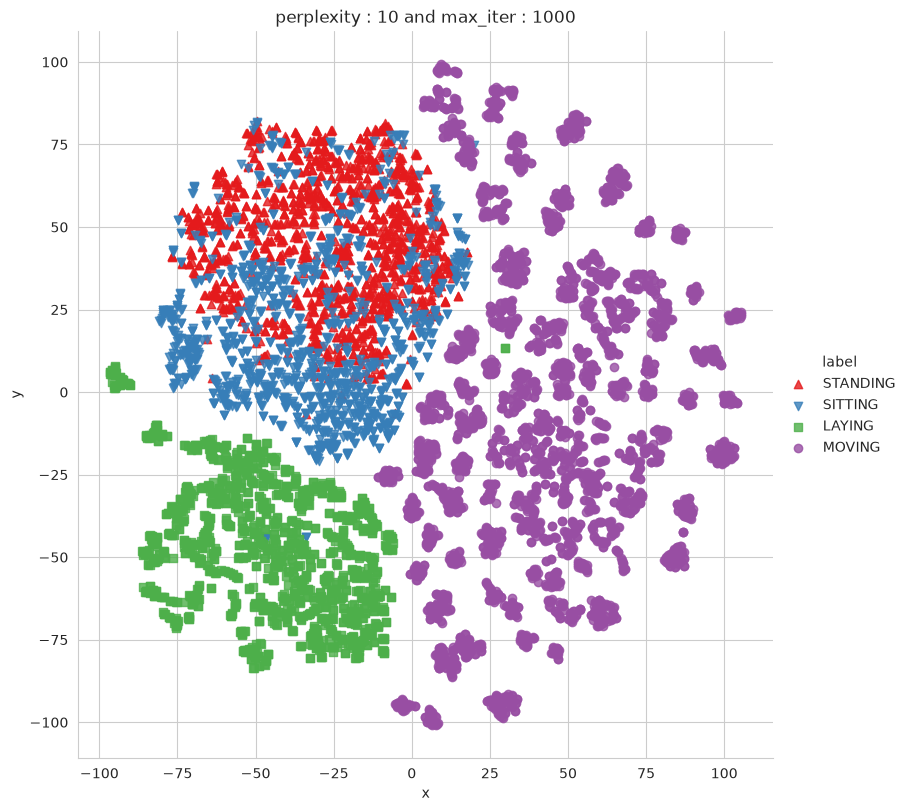

Done

performing tsne with perplexity 20 and with 1000 iterations at max
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.022s...


[t-SNE] Computed neighbors for 7352 samples in 1.252s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 1.274336
[t-SNE] Computed conditional probabilities in 0.103s


[t-SNE] Iteration 50: error = 89.2977676, gradient norm = 0.0298338 (50 iterations in 2.854s)


[t-SNE] Iteration 100: error = 83.0309143, gradient norm = 0.0080055 (50 iterations in 1.567s)


[t-SNE] Iteration 150: error = 81.6144104, gradient norm = 0.0042760 (50 iterations in 1.518s)


...

[t-SNE] Iteration 850: error = 1.4569709, gradient norm = 0.0054647 (50 iterations in 1.244s)


[t-SNE] Iteration 900: error = 1.4432495, gradient norm = 0.0049896 (50 iterations in 1.228s)


[t-SNE] Iteration 950: error = 1.4316194, gradient norm = 0.0045091 (50 iterations in 1.227s)


[t-SNE] Iteration 1000: error = 1.4221072, gradient norm = 0.0039007 (50 iterations in 1.311s)
[t-SNE] KL divergence after 1000 iterations: 1.422107
Done..
Creating plot for this t-sne visualization..


saving this plot as image in present working directory...


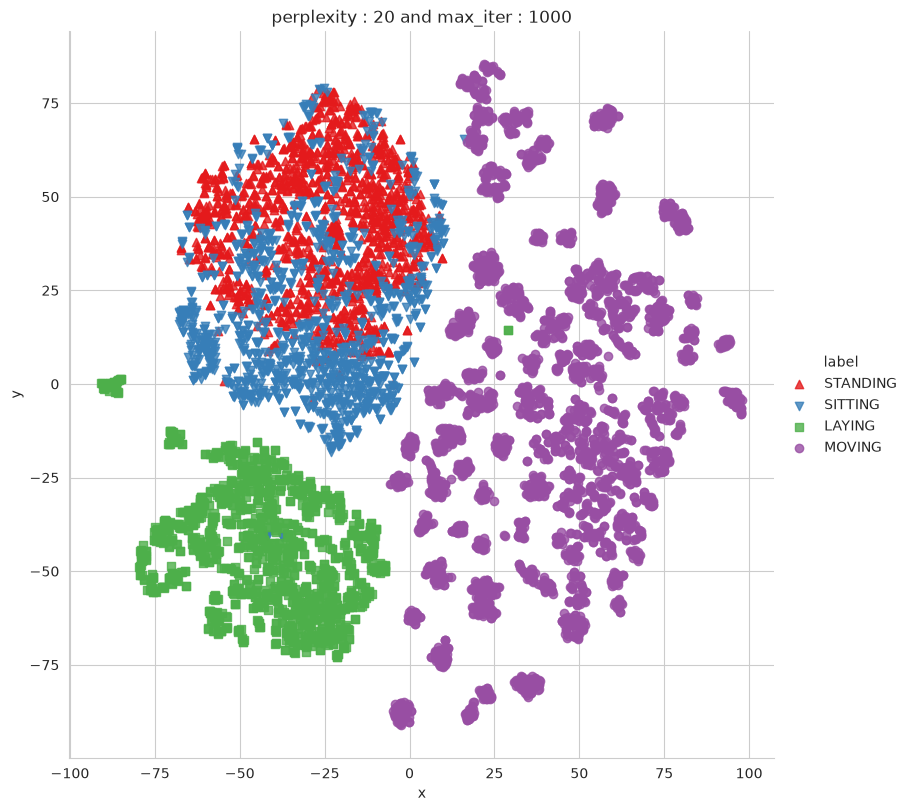

Done

performing tsne with perplexity 50 and with 1000 iterations at max
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.022s...


[t-SNE] Computed neighbors for 7352 samples in 1.491s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352


[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 1.437672
[t-SNE] Computed conditional probabilities in 0.283s


[t-SNE] Iteration 50: error = 78.8881531, gradient norm = 0.0246949 (50 iterations in 4.287s)


[t-SNE] Iteration 100: error = 75.2826080, gradient norm = 0.0059583 (50 iterations in 2.186s)


...

[t-SNE] Iteration 850: error = 1.3116188, gradient norm = 0.0037756 (50 iterations in 1.559s)


[t-SNE] Iteration 900: error = 1.3050957, gradient norm = 0.0032276 (50 iterations in 1.586s)


[t-SNE] Iteration 950: error = 1.2997780, gradient norm = 0.0028874 (50 iterations in 1.463s)


[t-SNE] Iteration 1000: error = 1.2953708, gradient norm = 0.0025757 (50 iterations in 1.509s)
[t-SNE] KL divergence after 1000 iterations: 1.295371
Done..
Creating plot for this t-sne visualization..


saving this plot as image in present working directory...


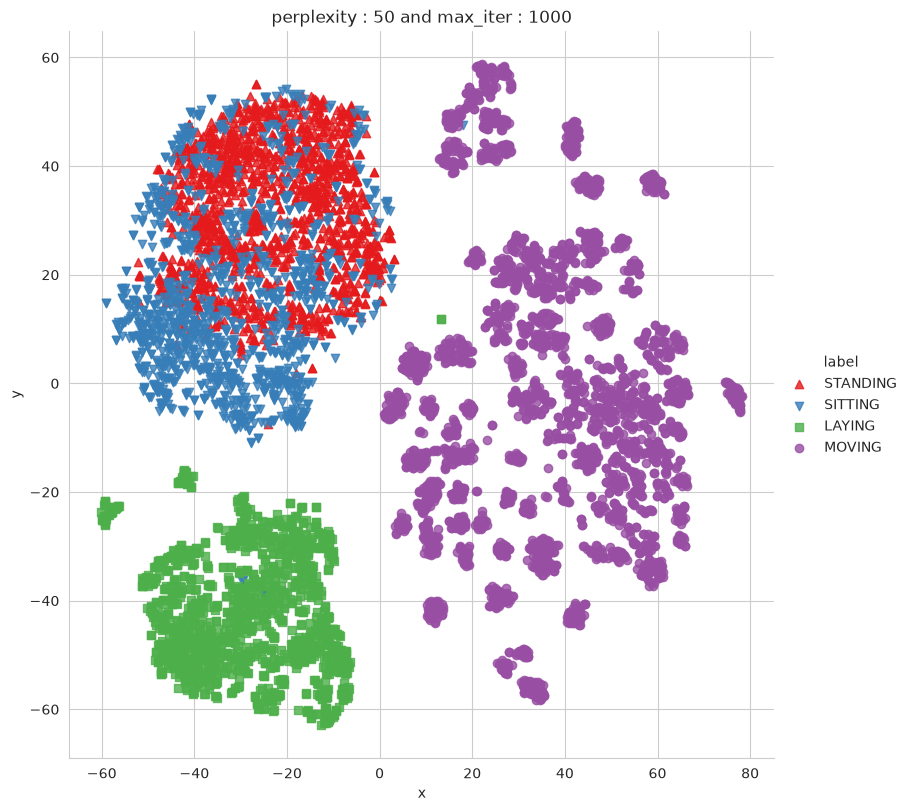

Done


In [ ]:
X_pre_tsne = train.drop(['subject', 'Activity','ActivityName'], axis=1)
y_pre_tsne = train['ActivityName']
perform_tsne(X_data = X_pre_tsne,y_data=y_pre_tsne, perplexities =[2,5,10,20,50])

We can clearly see the TSNE cluster, All the Activity are clean seperate except "Standing" and "Sitting".

# **Train Test Split**

In [ ]:
X_train = train.drop(['subject', 'Activity', 'ActivityName'], axis=1)
y_train = train.ActivityName

X_test = test.drop(['subject', 'Activity', 'ActivityName'], axis=1)
y_test = test.ActivityName

print('X_train and y_train : ({},{})'.format(X_train.shape, y_train.shape))
print('X_test  and y_test  : ({},{})'.format(X_test.shape, y_test.shape))

X_train and y_train : ((7352, 561),(7352,))
X_test  and y_test  : ((2947, 561),(2947,))


## **Define Labels that are useful in plotting confusion matrix**

In [ ]:
labels = ['LAYING', 'SITTING','STANDING','WALKING','WALKING_DOWNSTAIRS','WALKING_UPSTAIRS']
labels

['LAYING',
 'SITTING',
 'STANDING',
 'WALKING',
 'WALKING_DOWNSTAIRS',
 'WALKING_UPSTAIRS']

## **function to plot the confusion matrix**

In [ ]:
plt.rcParams["font.family"] = 'DejaVu Sans'

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

## **function to run any model specified**

In [ ]:
from datetime import datetime
def perform_model(model, X_train, y_train, X_test, y_test, class_labels, cm_normalize=True, \
                 print_cm=True, cm_cmap=plt.cm.Greens):


    # to store results at various phases
    results = dict()

    # time at which model starts training
    train_start_time = datetime.now()
    print('training the model..')
    model.fit(X_train, y_train)
    print('Done....!\n')
    train_end_time = datetime.now()
    results['training_time'] =  train_end_time - train_start_time
    print('==> training time:- {}\n'.format(results['training_time']))


    # predict test data
    print('Predicting test data')
    test_start_time = datetime.now()
    y_pred = model.predict(X_test)
    test_end_time = datetime.now()
    print('Done....!\n')
    results['testing_time'] = test_end_time - test_start_time
    print('==> testing time:- {}\n'.format(results['testing_time']))
    results['predicted'] = y_pred


    # calculate overall accuracty of the model
    accuracy = metrics.accuracy_score(y_true=y_test, y_pred=y_pred)
    # store accuracy in results
    results['accuracy'] = accuracy
    print('==> Accuracy:- {}\n'.format(accuracy))



    # confusion matrix
    cm = metrics.confusion_matrix(y_test, y_pred)
    results['confusion_matrix'] = cm
    if print_cm:
        print('\n ********Confusion Matrix********')
        print('\n {}'.format(cm))

    # plot confusin matrix
    plt.figure(figsize=(6,6))
    plt.grid(visible=False)
    plot_confusion_matrix(cm, classes=class_labels, normalize=True, title='Normalized confusion matrix', cmap = cm_cmap)
    plt.show()

    # get classification report
    print('****************| Classifiction Report |****************')
    classification_report = metrics.classification_report(y_test, y_pred)

    # store report in results
    results['classification_report'] = classification_report
    print(classification_report)

    # add the trained  model to the results
    results['model'] = model

    return results

## **function to print the gridsearch Parameters**

In [ ]:
def print_grid_search_attributes(model):
    # Estimator that gave highest score among all the estimators formed in GridSearch
    print('\n\n==> Best Estimator:')
    print('\t{}\n'.format(model.best_estimator_))


    # parameters that gave best results while performing grid search
    print('\n==> Best parameters:')
    print('\tParameters of best estimator : {}'.format(model.best_params_))


    #  number of cross validation splits
    print('\n==> No. of CrossValidation sets:')
    print('\tTotal numbre of cross validation sets: {}'.format(model.n_splits_))


    # Average cross validated score of the best estimator, from the Grid Search
    print('\n==> Best Score:')
    print('\tAverage Cross Validate scores of best estimator : {}'.format(model.best_score_))

# **1. Logistic Regression with Grid Search**

In [ ]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from datetime import datetime

from sklearn import linear_model
from sklearn import metrics

from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

import warnings
from sklearn.exceptions import ConvergenceWarning

training the model..
Fitting 3 folds for each of 12 candidates, totalling 36 fits


Done....!

==> training time:- 0:00:10.007699

Predicting test data
Done....!

==> testing time:- 0:00:00.010290

==> Accuracy:- 0.9755683746182559


 ********Confusion Matrix********

 [[ 537    0    0    0]
 [   0 1387    0    0]
 [   0    1  432   58]
 [   0    1   12  519]]


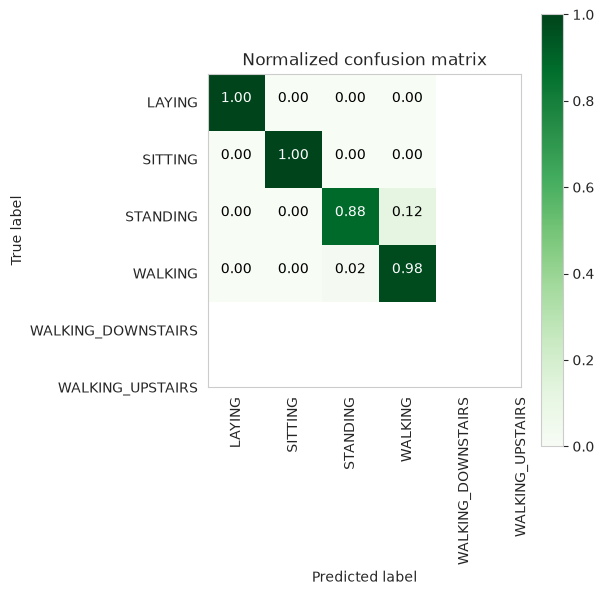

****************| Classifiction Report |****************
              precision    recall  f1-score   support

      LAYING       1.00      1.00      1.00       537
      MOVING       1.00      1.00      1.00      1387
     SITTING       0.97      0.88      0.92       491
    STANDING       0.90      0.98      0.94       532

    accuracy                           0.98      2947
   macro avg       0.97      0.96      0.96      2947
weighted avg       0.98      0.98      0.98      2947



==> Best Estimator:
	LogisticRegression(C=1, penalty='l2')


==> Best parameters:
	Parameters of best estimator : {'C': 1, 'penalty': 'l2'}

==> No. of CrossValidation sets:
	Total numbre of cross validation sets: 3

==> Best Score:
	Average Cross Validate scores of best estimator : 0.9703485735379423


In [ ]:
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=ConvergenceWarning)

# start Grid search
parameters = {'C':[0.01, 0.1, 1, 10, 20, 30], 'penalty':['l2','l1']}
log_reg = linear_model.LogisticRegression()
log_reg_grid = GridSearchCV(log_reg, param_grid=parameters, cv=3, verbose=1, n_jobs=4)
log_reg_grid_results =  perform_model(log_reg_grid, X_train, y_train, X_test, y_test, class_labels=labels)

# observe the attributes of the model
print_grid_search_attributes(log_reg_grid_results['model'])

# **2. Linear SVC with GridSearch**

training the model..
Fitting 5 folds for each of 6 candidates, totalling 30 fits


Done....!

==> training time:- 0:00:12.830355

Predicting test data
Done....!

==> testing time:- 0:00:00.009385

==> Accuracy:- 0.9759077027485579


 ********Confusion Matrix********

 [[ 537    0    0    0]
 [   0 1387    0    0]
 [   2    1  430   58]
 [   0    1    9  522]]


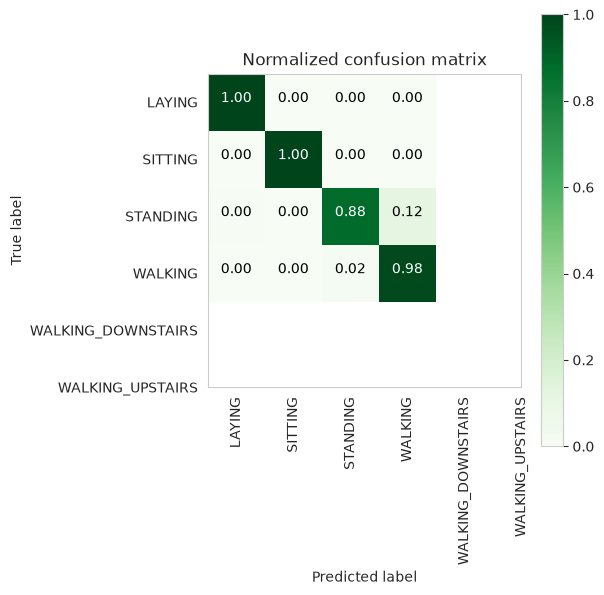

****************| Classifiction Report |****************
              precision    recall  f1-score   support

      LAYING       1.00      1.00      1.00       537
      MOVING       1.00      1.00      1.00      1387
     SITTING       0.98      0.88      0.92       491
    STANDING       0.90      0.98      0.94       532

    accuracy                           0.98      2947
   macro avg       0.97      0.96      0.97      2947
weighted avg       0.98      0.98      0.98      2947



==> Best Estimator:
	LinearSVC(C=0.5, tol=5e-05)


==> Best parameters:
	Parameters of best estimator : {'C': 0.5}

==> No. of CrossValidation sets:
	Total numbre of cross validation sets: 5

==> Best Score:
	Average Cross Validate scores of best estimator : 0.9757898047050227


In [ ]:
parameters = {'C':[0.125, 0.5, 1, 2, 8, 16]}
lr_svc = LinearSVC(tol=0.00005)
lr_svc_grid = GridSearchCV(lr_svc, param_grid=parameters, n_jobs=4, verbose=1)
lr_svc_grid_results = perform_model(lr_svc_grid, X_train, y_train, X_test, y_test, class_labels=labels)

# observe the attributes of the model
print_grid_search_attributes(lr_svc_grid_results['model'])

# **3. Kernel SVM with GridSearch**

training the model..


Done....!

==> training time:- 0:02:11.767916

Predicting test data


Done....!

==> testing time:- 0:00:00.702311

==> Accuracy:- 0.9793009840515778


 ********Confusion Matrix********

 [[ 537    0    0    0]
 [   0 1387    0    0]
 [   0    1  442   48]
 [   0    0   12  520]]


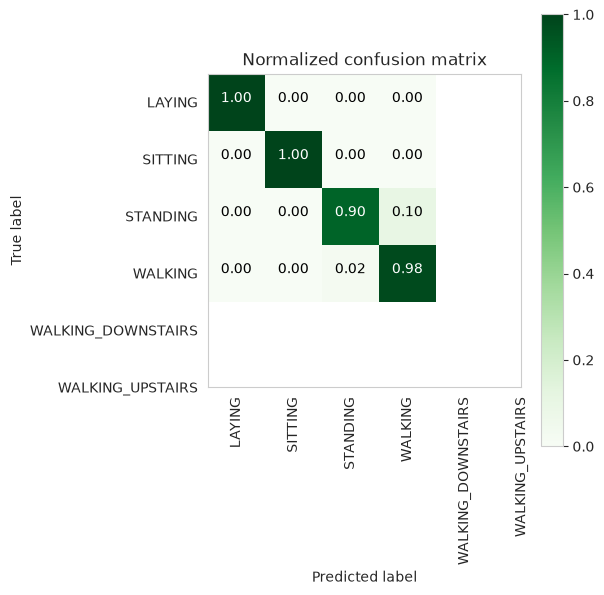

****************| Classifiction Report |****************


              precision    recall  f1-score   support

      LAYING       1.00      1.00      1.00       537
      MOVING       1.00      1.00      1.00      1387
     SITTING       0.97      0.90      0.94       491
    STANDING       0.92      0.98      0.95       532

    accuracy                           0.98      2947
   macro avg       0.97      0.97      0.97      2947
weighted avg       0.98      0.98      0.98      2947



==> Best Estimator:
	SVC(C=16, gamma=0.0078125)


==> Best parameters:
	Parameters of best estimator : {'C': 16, 'gamma': 0.0078125}

==> No. of CrossValidation sets:
	Total numbre of cross validation sets: 5

==> Best Score:
	Average Cross Validate scores of best estimator : 0.9755172334059388


In [ ]:
parameters = {'C':[2,8,16],\
              'gamma': [ 0.0078125, 0.125, 2]}
rbf_svm = SVC(kernel='rbf')
rbf_svm_grid = GridSearchCV(rbf_svm,param_grid=parameters, n_jobs=4)
rbf_svm_grid_results = perform_model(rbf_svm_grid, X_train, y_train, X_test, y_test, class_labels=labels)

# observe the attributes of the model
print_grid_search_attributes(rbf_svm_grid_results['model'])

# **4. Decision Trees with GridSearchCV**

training the model..


Done....!

==> training time:- 0:00:08.664241

Predicting test data
Done....!

==> testing time:- 0:00:00.008857

==> Accuracy:- 0.9328130302002036


 ********Confusion Matrix********

 [[ 537    0    0    0]
 [   0 1387    0    0]
 [   0    0  400   91]
 [   0    0  107  425]]


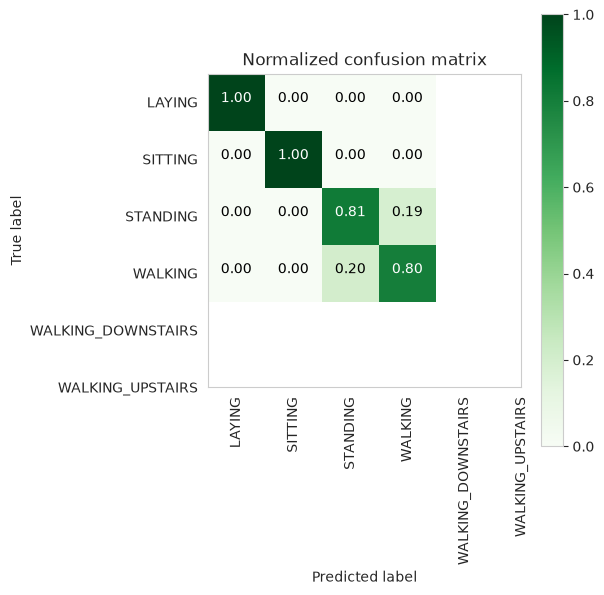

****************| Classifiction Report |****************
              precision    recall  f1-score   support

      LAYING       1.00      1.00      1.00       537
      MOVING       1.00      1.00      1.00      1387
     SITTING       0.79      0.81      0.80       491
    STANDING       0.82      0.80      0.81       532

    accuracy                           0.93      2947
   macro avg       0.90      0.90      0.90      2947
weighted avg       0.93      0.93      0.93      2947



==> Best Estimator:
	DecisionTreeClassifier(max_depth=np.int64(3))


==> Best parameters:
	Parameters of best estimator : {'max_depth': np.int64(3)}

==> No. of CrossValidation sets:
	Total numbre of cross validation sets: 5

==> Best Score:
	Average Cross Validate scores of best estimator : 0.9508989673367647


In [ ]:
parameters = {'max_depth':np.arange(3,10,2)}
dt = DecisionTreeClassifier()
dt_grid = GridSearchCV(dt,param_grid=parameters, n_jobs=4)
dt_grid_results = perform_model(dt_grid, X_train, y_train, X_test, y_test, class_labels=labels)

# observe the attributes of the model
print_grid_search_attributes(dt_grid_results['model'])

# **5. Random Forest Classifier with GridSearch**

training the model..


Done....!

==> training time:- 0:05:39.173838

Predicting test data
Done....!

==> testing time:- 0:00:00.017974

==> Accuracy:- 0.9687818120122158


 ********Confusion Matrix********

 [[ 537    0    0    0]
 [   0 1387    0    0]
 [   0    0  432   59]
 [   0    0   33  499]]


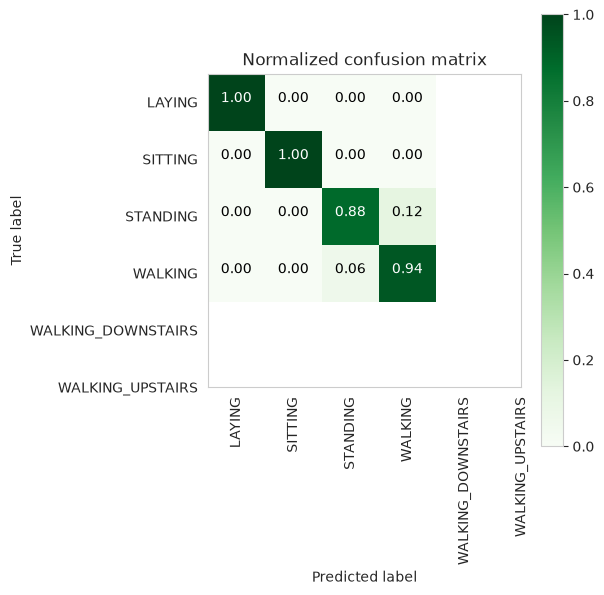

****************| Classifiction Report |****************
              precision    recall  f1-score   support

      LAYING       1.00      1.00      1.00       537
      MOVING       1.00      1.00      1.00      1387
     SITTING       0.93      0.88      0.90       491
    STANDING       0.89      0.94      0.92       532

    accuracy                           0.97      2947
   macro avg       0.96      0.95      0.95      2947
weighted avg       0.97      0.97      0.97      2947



==> Best Estimator:
	RandomForestClassifier(max_depth=np.int64(13), n_estimators=np.int64(50))


==> Best parameters:
	Parameters of best estimator : {'max_depth': np.int64(13), 'n_estimators': np.int64(50)}

==> No. of CrossValidation sets:
	Total numbre of cross validation sets: 5

==> Best Score:
	Average Cross Validate scores of best estimator : 0.9623241165942924


In [ ]:
params = {'n_estimators': np.arange(10,201,20), 'max_depth':np.arange(3,15,2)}
rfc = RandomForestClassifier()
rfc_grid = GridSearchCV(rfc, param_grid=params, n_jobs=4)
rfc_grid_results = perform_model(rfc_grid, X_train, y_train, X_test, y_test, class_labels=labels)

# observe the attributes of the model
print_grid_search_attributes(rfc_grid_results['model'])

# **6. Gradient Boosted Decision Trees With GridSearch**

training the model..


Done....!

==> training time:- 0:23:11.225883

Predicting test data
Done....!

==> testing time:- 0:00:00.027308

==> Accuracy:- 0.9599592806243638


 ********Confusion Matrix********

 [[ 537    0    0    0]
 [   0 1387    0    0]
 [   0    0  414   77]
 [   0    0   41  491]]


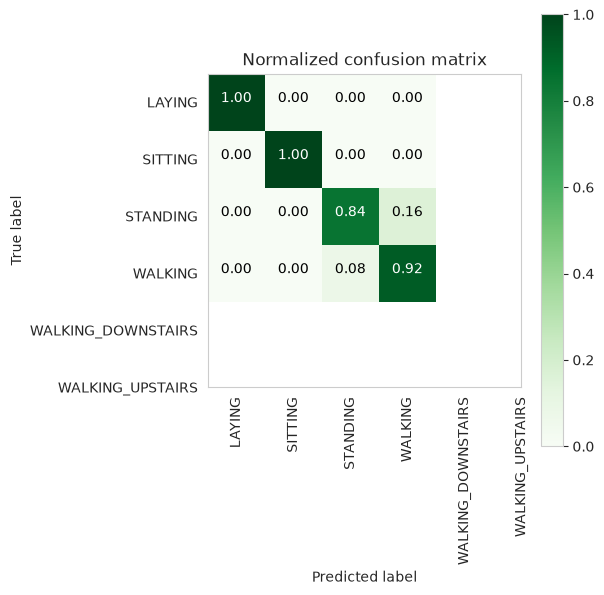

****************| Classifiction Report |****************
              precision    recall  f1-score   support

      LAYING       1.00      1.00      1.00       537
      MOVING       1.00      1.00      1.00      1387
     SITTING       0.91      0.84      0.88       491
    STANDING       0.86      0.92      0.89       532

    accuracy                           0.96      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.96      0.96      0.96      2947



==> Best Estimator:
	GradientBoostingClassifier()


==> Best parameters:
	Parameters of best estimator : {'max_depth': 3, 'n_estimators': 100}

==> No. of CrossValidation sets:
	Total numbre of cross validation sets: 3

==> Best Score:
	Average Cross Validate scores of best estimator : 0.952937604254268


In [ ]:
param_grid = {'max_depth': [3, 5], 'n_estimators': [100]}  # patched: small valid grid (original 5x140 incl. invalid 0s)
gbdt = GradientBoostingClassifier()
gbdt_grid = GridSearchCV(gbdt, param_grid=param_grid, cv=3, n_jobs=4)
gbdt_grid_results = perform_model(gbdt_grid, X_train, y_train, X_test, y_test, class_labels=labels)

# observe the attributes of the model
print_grid_search_attributes(gbdt_grid_results['model'])

# **7. Comparing all models**

In [ ]:
# ***************************** Print Accuracy and Error ******************************

print('\n                     Accuracy     Error')
print('                     ----------   --------')
print('Logistic Regression : {:.04}%       {:.04}%'.format(log_reg_grid_results['accuracy'] * 100,\
                                                  100-(log_reg_grid_results['accuracy'] * 100)))

print('Linear SVC          : {:.04}%       {:.04}% '.format(lr_svc_grid_results['accuracy'] * 100,\
                                                        100-(lr_svc_grid_results['accuracy'] * 100)))

print('rbf SVM classifier  : {:.04}%      {:.04}% '.format(rbf_svm_grid_results['accuracy'] * 100,\
                                                          100-(rbf_svm_grid_results['accuracy'] * 100)))

print('DecisionTree        : {:.04}%      {:.04}% '.format(dt_grid_results['accuracy'] * 100,\
                                                        100-(dt_grid_results['accuracy'] * 100)))

print('Random Forest       : {:.04}%      {:.04}% '.format(rfc_grid_results['accuracy'] * 100,\
                                                           100-(rfc_grid_results['accuracy'] * 100)))


                     Accuracy     Error
                     ----------   --------
Logistic Regression : 97.56%       2.443%
Linear SVC          : 97.59%       2.409% 
rbf SVM classifier  : 97.93%      2.07% 
DecisionTree        : 93.28%      6.719% 
Random Forest       : 96.88%      3.122% 
